# Surrogate model architecture (ModularMLP)

Explains the neural surrogate that stands in for TraceWin inside `SurrogateEnv` /
`DifferentiableSurrogateEnv`: its exact input/output contract and its layer-by-layer structure
(`beam_optimization/env/surrogate_env/surrogate/model/modular_mlp.py`).

This notebook is read-only and scoped to **architecture only**: it instantiates a model in memory to
inspect its structure (layers, shapes, parameter counts), it does not train, fine-tune, or overwrite
any checkpoint, and it does not evaluate prediction accuracy -- that belongs in `evaluator.py` / a
dedicated results notebook, once a trained checkpoint exists.

**Related notebooks:**
- [`env/dataset/visualize_dataset.ipynb`](../../../dataset/visualize_dataset.ipynb) — the `BeamDataset`
  this model is trained on: per-parameter/per-stage statistics, distributions, correlations. The
  normalization statistics used below are computed directly from that same dataset.
- [`env/visualize_environments.ipynb`](../../../visualize_environments.ipynb) — section 0 explains the
  `BeamSimulator.simulate()` contract shared by `TraceWinSimulator` and `SurrogateBeamSimulator`; this
  notebook is the deep dive on what actually runs *inside* the surrogate half of that contract.

In [1]:
from pathlib import Path
import sys
import tempfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display

WORKING_DIR = Path.cwd().resolve()
if (WORKING_DIR / 'beam_optimization').is_dir():
    REPO_ROOT = WORKING_DIR
else:
    PROJECT_ROOT = WORKING_DIR
    while PROJECT_ROOT.name != 'beam_optimization' and PROJECT_ROOT.parent != PROJECT_ROOT:
        PROJECT_ROOT = PROJECT_ROOT.parent
    REPO_ROOT = PROJECT_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from beam_optimization.config.adige import (
    BEAM_STATE_DIM, BEAM_STATE_FEATURES, N_OUTPUT_STAGES, N_PARAMS, N_STAGES,
    PARAMETERS, STAGE_MARKERS, STAGE_PARAM_KEYS, STAGE_PARAM_SIZES,
)
from beam_optimization.config.paths import (
    DEFAULT_BASE_SURROGATE_DIR, DEFAULT_UPDATED_SURROGATE_DIR,
)
from beam_optimization.env.dataset import BeamDataset
from beam_optimization.env.surrogate_env.surrogate.model.modular_mlp import ModularMLP
from beam_optimization.env.surrogate_env.surrogate.model.failure_classifier import FailureClassifier
from beam_optimization.env.surrogate_env.surrogate.model.trainer import compute_normalization_metadata

torch.manual_seed(0)


def fmt(value):
    return f'{float(value):.6g}'


def table(headers, rows):
    lines = ['| ' + ' | '.join(headers) + ' |', '| ' + ' | '.join(['---'] * len(headers)) + ' |']
    lines.extend('| ' + ' | '.join(str(cell) for cell in row) + ' |' for row in rows)
    return '\n'.join(lines)


def stage_label(index):
    """Match the beam0/marker_X convention used throughout the project."""
    if index == 0:
        return 'beam0'
    return f'marker_{STAGE_MARKERS[index]}'


def count_params(module):
    return sum(p.numel() for p in module.parameters())

## 1. Input / output contract

`ModularMLP.forward(stage_params, beam_state_0)` maps **one initial beam state + the full set of
machine parameters** to a **predicted beam state at every one of the 12 output stages** -- exactly the
`(params, beam0) -> beam_states` contract `SurrogateBeamSimulator` needs to satisfy the
`BeamSimulator.simulate()` interface described in `visualize_environments.ipynb` section 0.

| | Shape | Meaning |
| --- | --- | --- |
| `beam_state_0` (input) | `(batch, BEAM_STATE_DIM=9)` | initial beam state, stage 0 -- same 9 features as `BEAM_STATE_FEATURES` in `visualize_dataset.ipynb` |
| `stage_params` (input) | list of `N_OUTPUT_STAGES=12` tensors, `(batch, stage_size)` | all `N_PARAMS=18` machine parameters, pre-grouped by which lattice section (output stage) they physically act in |
| return value (output) | list of `N_OUTPUT_STAGES=12` tensors, `(batch, BEAM_STATE_DIM=9)` | predicted beam state at each stage marker, in the same units/order as the dataset's `Y` columns |

The grouping of the 18 parameters into 12 stage-sized chunks is not arbitrary -- it follows where each
parameter physically sits along the ADIGE lattice (`STAGE_MARKERS`), computed once in `adige.py` and
reused everywhere (dataset storage, this model, `SurrogateBeamSimulator`). A parameter assigned to
stage *s* only becomes visible to the network when its stage block is reached, mirroring how a real
downstream element cannot affect beam states computed upstream of it.

In [2]:
rows = []
for s_idx in range(N_OUTPUT_STAGES):
    keys = STAGE_PARAM_KEYS[s_idx]
    rows.append([
        s_idx + 1, f'`{stage_label(s_idx + 1)}`', STAGE_PARAM_SIZES[s_idx],
        ', '.join(f'`{k}`' for k in keys),
    ])

display(Markdown('\n\n'.join([
    '### Parameter grouping per output stage (`STAGE_PARAM_KEYS` / `STAGE_PARAM_SIZES`)',
    table(['Output stage', 'Label', '# params', 'Parameter keys'], rows),
    f'Total: {sum(STAGE_PARAM_SIZES)} parameters across {N_OUTPUT_STAGES} stages '
    f'(must equal N_PARAMS={N_PARAMS}, checked by an assertion in `adige.py`).',
])))

### Parameter grouping per output stage (`STAGE_PARAM_KEYS` / `STAGE_PARAM_SIZES`)

| Output stage | Label | # params | Parameter keys |
| --- | --- | --- | --- |
| 1 | `marker_2` | 1 | `ele[2][5]` |
| 2 | `marker_29` | 1 | `ele[29][5]` |
| 3 | `marker_108` | 2 | `ele[38][1]`, `ele[38][2]` |
| 4 | `marker_151` | 1 | `ele[151][2]` |
| 5 | `marker_162` | 2 | `ele[162][1]`, `ele[162][2]` |
| 6 | `marker_195` | 1 | `ele[195][2]` |
| 7 | `marker_197` | 1 | `ele[197][5]` |
| 8 | `marker_203` | 4 | `ele[200][6]`, `ele[201][6]`, `ele[202][6]`, `ele[203][6]` |
| 9 | `marker_205` | 1 | `ele[205][5]` |
| 10 | `marker_225` | 1 | `ele[225][2]` |
| 11 | `marker_261` | 2 | `ele[261][1]`, `ele[261][2]` |
| 12 | `marker_332` | 1 | `ele[280][2]` |

Total: 18 parameters across 12 stages (must equal N_PARAMS=18, checked by an assertion in `adige.py`).

## 2. Checkpoint availability

Before inspecting weights, check what is actually saved on disk right now.

In [3]:
# Keep the architecture inspection tied to one explicit, matching training dataset/checkpoint.
MODEL_PATH = DEFAULT_BASE_SURROGATE_DIR / 'surrogate_018_0.pt'
DATASET_PATH = REPO_ROOT / 'beam_optimization/env/dataset/018/dataset_train.pt'

base_ckpts = sorted(DEFAULT_BASE_SURROGATE_DIR.glob('surrogate_*.pt')) if DEFAULT_BASE_SURROGATE_DIR.exists() else []
updated_ckpts = sorted(DEFAULT_UPDATED_SURROGATE_DIR.glob('surrogate_*.pt')) if DEFAULT_UPDATED_SURROGATE_DIR.exists() else []

print(f'base ({DEFAULT_BASE_SURROGATE_DIR}): {len(base_ckpts)} checkpoint(s)')
print(f'updated ({DEFAULT_UPDATED_SURROGATE_DIR}): {len(updated_ckpts)} checkpoint(s)')

if not DATASET_PATH.exists():
    raise FileNotFoundError(f'Matching training dataset not found: {DATASET_PATH}')
dataset_id = DATASET_PATH.parent.name
model_dataset_id = MODEL_PATH.stem[len('surrogate_'):].rsplit('_', 1)[0]
if model_dataset_id != dataset_id:
    raise ValueError(f'Checkpoint/dataset mismatch: model={model_dataset_id}, dataset={dataset_id}')
dataset = BeamDataset.load(DATASET_PATH)
norm_stats = compute_normalization_metadata(dataset)

if MODEL_PATH.exists():
    model = ModularMLP.load(MODEL_PATH)
    print(f'\nLoaded trained checkpoint: {MODEL_PATH.name}')
    print(f'Matching normalization dataset: {DATASET_PATH}')
else:
    model = ModularMLP(norm_stats=norm_stats)
    print(f'\nNo trained checkpoint found in either directory yet (train one with the '
          f'`train_surrogate` command). Building a freshly-initialized ModularMLP instead, with '
          f'normalization statistics computed from `{DATASET_PATH.name}` -- this is enough to inspect '
          f'the architecture and shape flow; weights are random, so predicted *values* below are not '
          f'meaningful, only shapes and normalization are.')
model.eval();

base (/mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/surrogate_env/surrogate/trained_models/base): 2 checkpoint(s)
updated (/mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/surrogate_env/surrogate/trained_models/updated): 0 checkpoint(s)


[BeamDataset] 28,000 samples loaded from /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/dataset/018/dataset_train.pt

Loaded trained checkpoint: surrogate_018_0.pt
Matching normalization dataset: /mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/dataset/018/dataset_train.pt


## 3. Layer-by-layer structure

Per the module's own docstring: *"Architecture mirrors the physical structure: one sub-network per
accelerator stage."* Concretely, three groups of sub-networks share a 64-dim (`latent_dim`) "beam
latent" that is threaded through the whole chain:

- **`input_net`** (stage 0 fusion) -- the *only* net that sees the raw initial beam state. Consumes
  `beam_state_0 (9) ⊕ params[0] (1)` = 10 features, and produces the first latent `z0`.
- **`stage_nets[0..10]`** (11 nets, one per remaining output stage `i = 1..11`) -- each consumes
  `[z_{i-1} (64) ⊕ params[i]]` and produces a **residual update**: `z_i = stage_nets[i-1](...) + z_{i-1}`.
  Every stage has its **own weights** (not shared/tied across stages) -- the network literally
  dedicates one sub-network per accelerator section, chained through the evolving latent rather than
  run independently or off one shared trunk.
- **`output_nets[0..11]`** (12 nets, one per output stage) -- each reads the *current* latent `z_i` and
  regresses the 9-dim beam state at that stage. No activation on the final `Linear` layer itself (a raw
  regression head), but the denormalized output of every stage is then passed through
  `_apply_physical_bounds()`: `SizeX`/`SizeY`/`ex`/`ey` clamped to `>= 0` (offsets/angles `x0`/`y0`/`x'0`/`y'0`
  are left unconstrained -- they are signed displacements from a zero reference, not bounded quantities), and
  `npart_ratio` reconstructed with `sigmoid()` instead of a clamp -- see section 3.4 for why this one feature
  gets different treatment. Both are parameter-free transforms (no learned weights) applied identically during
  training and inference, added specifically because unconstrained regression could otherwise predict
  physically impossible values (e.g. negative `SizeX`) that `score()` would then turn into arbitrarily large
  rewards/penalties instead of a bounded, physically-meaningful error.

Every hidden `Linear` is followed by `LayerNorm` + `ReLU` + `Dropout` (a single shared `nn.ReLU()`
instance is reused everywhere since it is stateless); the final projection to `latent_dim` in
`input_net`/`stage_nets` keeps `LayerNorm` + `ReLU` but drops `Dropout`, and the final projection to
`BEAM_STATE_DIM` in `output_nets` has no normalization/activation at all (the physical-bounds
reconstruction described above happens afterward, outside `output_nets` itself, in `forward()`).

In [4]:
print('input_net:')
print(model.input_net)
print(f'\n... {count_params(model.input_net):,} parameters')

print('\nstage_nets[0] (output stage 2, first residual block):')
print(model.stage_nets[0])
print(f'\n... {count_params(model.stage_nets[0]):,} parameters')

print('\noutput_nets[0] (output stage 1 head):')
print(model.output_nets[0])
print(f'\n... {count_params(model.output_nets[0]):,} parameters')

input_net:
Sequential(
  (0): Linear(in_features=10, out_features=256, bias=True)
  (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (2): ReLU()
  (3): Dropout(p=0.15, inplace=False)
  (4): Linear(in_features=256, out_features=256, bias=True)
  (5): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (6): ReLU()
  (7): Dropout(p=0.15, inplace=False)
  (8): Linear(in_features=256, out_features=256, bias=True)
  (9): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (10): ReLU()
  (11): Dropout(p=0.15, inplace=False)
  (12): Linear(in_features=256, out_features=64, bias=True)
  (13): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (14): ReLU()
)

... 152,512 parameters

stage_nets[0] (output stage 2, first residual block):
Sequential(
  (0): Linear(in_features=65, out_features=256, bias=True)
  (1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (2): ReLU()
  (3): Dropout(p=0.15, inplace=False)
  (4): Linear(in_features=256, out_features=256, bias=Tr

In [5]:
rows = [['input_net', 1, count_params(model.input_net)]]
rows.append(['stage_nets', len(model.stage_nets), sum(count_params(m) for m in model.stage_nets)])
rows.append(['output_nets', len(model.output_nets), sum(count_params(m) for m in model.output_nets)])
total = count_params(model)

display(Markdown('\n\n'.join([
    '### Parameter count by block',
    table(['Block', '# sub-networks', 'Parameters (all instances)'],
          [[b, n, f'{p:,}'] for b, n, p in rows]),
    f'**Total trainable parameters: {total:,}** '
    f'(hidden_sizes={model.hidden_sizes}, latent_dim={model.latent_dim}, out_hidden={model.out_hidden}, '
    f'dropout={model.dropout}, out_dropout={model.out_dropout})',
])))

### Parameter count by block

| Block | # sub-networks | Parameters (all instances) |
| --- | --- | --- |
| input_net | 1 | 152,512 |
| stage_nets | 11 | 1,834,048 |
| output_nets | 12 | 1,029,228 |

**Total trainable parameters: 3,015,788** (hidden_sizes=[256, 256, 256], latent_dim=64, out_hidden=[256, 256], dropout=0.15, out_dropout=0.15)

### 3.1 Diagram: how data flows through the layers, stage by stage

![ModularMLP architecture diagram](../modular_mlp_diagram.png)

Reading the picture left to right, one "block" per output stage:

- **Red dots** -- the initial beam state `beam_state_0` (9 numbers) plus stage 0's machine parameters:
  the only raw physical input the network sees directly, at the very start of the chain.
- **Orange dots** -- the machine parameters belonging to that stage (`STAGE_PARAM_SIZES[i]` numbers),
  joined onto the latent right before that stage's hidden layers.
- **Blue dots** -- hidden layers, always 256 units wide (`Linear -> LayerNorm -> ReLU -> Dropout`):
  three of them in the *top* row (updating the latent), two in the *bottom* row (producing that
  stage's prediction).
- **Green dots** -- the 64-number "beam latent" (`latent_dim`) threaded from stage to stage. The
  dashed arrows with a `+` mark the residual connection: each stage's latent is the *previous* latent
  plus that stage's update, not something recomputed from scratch.
- **Purple dots** -- the predicted 9-number beam state for that stage, i.e. what is compared against
  the dataset's true beam states and what `SurrogateBeamSimulator` reads out. Not shown as a separate
  node (it adds no width/layer, just reconstructs the values already there): right after this point,
  `_apply_physical_bounds()` clips `SizeX`/`SizeY`/`ex`/`ey` to `>= 0`, and reconstructs `npart_ratio`
  with `sigmoid()` (see section 3.4) rather than clipping it, before the stage's prediction is returned
  (see section 3, above).
- **OBS: yes/no** -- whether that stage's beam state is part of the RL agent's observation vector
  (`OBSERVATION_STAGE_MASK` in `adige.py`, covered in `visualize_environments.ipynb`). The surrogate
  always predicts all 12 stages regardless; the RL environment simply chooses to show the agent a
  subset of them.

So every block in the picture is really **two small networks sharing one latent**: a *top* network
(`stage_nets[i]`) that updates the latent for the next stage, and a *bottom* network (`output_nets[i]`)
that reads the current latent and turns it into that stage's predicted beam state.

### 3.2 Chain diagram, in the code's own names

Same structure as above, redrawn with the actual `input_net` / `stage_nets[i]` / `output_nets[i]` / `z_i`
names used in `forward()`, so it's easy to match each arrow directly to a line of code.

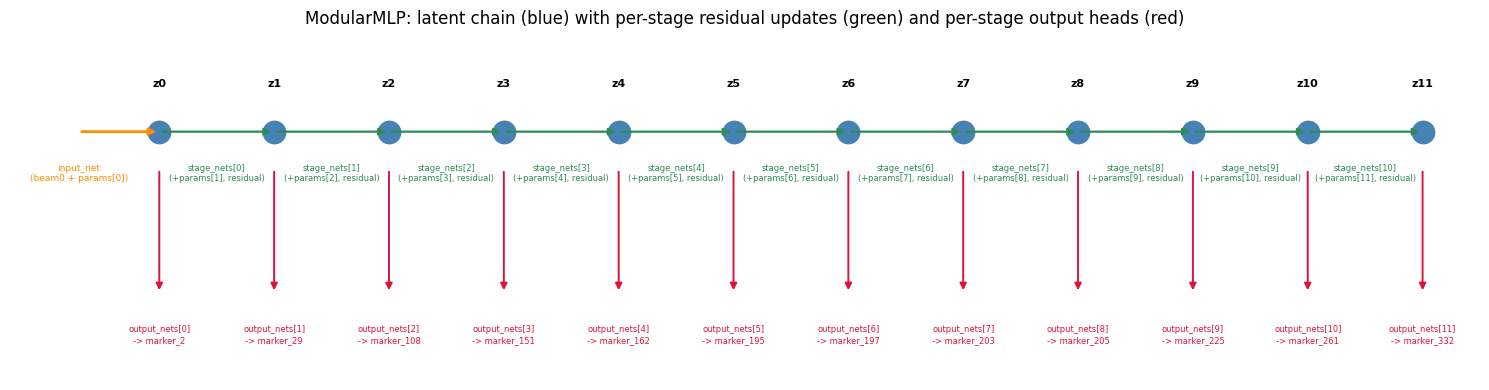

In [6]:
fig, ax = plt.subplots(figsize=(15, 4))
n = N_OUTPUT_STAGES
x_latent = np.arange(n)  # z0..z11 positions (n latent nodes: after input_net, after each of the 11 stage_nets)

# Latent nodes
for i, x in enumerate(x_latent):
    ax.scatter(x, 1, s=260, color='steelblue', zorder=3)
    ax.text(x, 1.18, f'z{i}', ha='center', fontsize=8, fontweight='bold')

# input_net arrow into z0
ax.annotate('', xy=(0, 1), xytext=(-0.7, 1),
            arrowprops=dict(arrowstyle='-|>', color='darkorange', lw=2))
ax.text(-0.7, 0.8, 'input_net\n(beam0 + params[0])', ha='center', fontsize=6.5, color='darkorange')

# stage_nets residual arrows between latent nodes
for i in range(1, n):
    ax.annotate('', xy=(i, 1), xytext=(i - 1, 1),
                arrowprops=dict(arrowstyle='-|>', color='seagreen', lw=1.6))
    ax.text(i - 0.5, 0.8, f'stage_nets[{i-1}]\n(+params[{i}], residual)', ha='center', fontsize=6, color='seagreen')

# output_nets taps predicting each stage's beam state
for i, x in enumerate(x_latent):
    ax.annotate('', xy=(x, 0.35), xytext=(x, 0.85),
                arrowprops=dict(arrowstyle='-|>', color='crimson', lw=1.4))
    label = stage_label(i + 1)
    ax.text(x, 0.15, f'output_nets[{i}]\n-> {label}', ha='center', fontsize=6, color='crimson')

ax.set_xlim(-1.3, n - 0.5)
ax.set_ylim(0, 1.4)
ax.axis('off')
ax.set_title('ModularMLP: latent chain (blue) with per-stage residual updates (green) and per-stage output heads (red)')
fig.tight_layout()
plt.show()

### 3.3 `forward()`, step by step

Putting the diagrams above into the exact computation `ModularMLP.forward()` runs:

```
def forward(stage_params, beam_state_0):
    sp = normalize(stage_params)              # per-stage z-score, using pm_i/ps_i
    b0 = normalize(beam_state_0, stage=0)      # z-score, using bm_0/bs_0

    z = input_net(concat(b0, sp[0]))                        # stage 0 -> z0
    out0 = denormalize(output_nets[0](z), stage=1)
    outputs = [apply_physical_bounds(out0)]                  # predict stage 1

    for i in 1 .. N_OUTPUT_STAGES-1:
        z = stage_nets[i-1](concat(z, sp[i])) + z             # residual update -> z_i
        out_i = denormalize(output_nets[i](z), stage=i+1)
        outputs.append(apply_physical_bounds(out_i))

    return outputs   # 12 tensors, one predicted beam state per output stage
```

`apply_physical_bounds` (section 3, above) clamps `SizeX`/`SizeY`/`ex`/`ey` to `>= 0` and reconstructs
`npart_ratio` with `sigmoid()` (section 3.4) on every stage's denormalized output -- both are fixed,
parameter-free transforms (no learned weights). The `SizeX`/`SizeY`/`ex`/`ey` clamp changes what a
checkpoint predicts without requiring retraining -- checkpoints saved before it was added still load
and run correctly. **The `npart_ratio` treatment does not share that property**: `denormalize(...,
stage=i)` for that one column now assumes `bm_i`/`bs_i` were computed in logit space
(`compute_normalization_metadata()`, section 3.4), so a checkpoint trained before this change stores
raw-space statistics for that column and is not compatible with the new `forward()` -- it must be
retrained.

### 3.4 Why `npart_ratio` uses logit-space normalization, not plain z-score

`npart_ratio` is a proportion in `[0, 1]`, and it is heavily concentrated near zero: 26% of a typical
dataset falls in `[0, 0.05)`. Z-score normalization (what every other feature uses) is a **linear**
transform -- it shifts and scales, but does not "unsquish" a distribution piled up against a boundary.
The network had to represent fine distinctions (e.g. `0.001` vs `0.02`) using the same resolution it
uses everywhere else, right where the most precision is needed.

**The old failure mode this caused**: the network's raw output for `npart_ratio` was denormalized
directly into a proportion, then clamped to `[0, 1]`. Regression noise (measured on this project's
dataset: std ≈ 0.034 in the `[0, 0.15]` band) would occasionally push a low-but-nonzero true value's
prediction slightly negative, and the clamp turned it into an **exact 0.0** -- read by `score()` as
"all particles lost" (`is_all_particles_lost()`, `adige.py`) even when the true beam was merely
low-transmission. Measured: **13.2%** of predictions in that band were clamped to exactly zero this way.

**The fix**: `compute_normalization_metadata()` (`trainer.py`) computes `npart_ratio`'s mean/std at
every *output* stage from `logit(p) = log(p / (1-p))` instead of raw `p` (via `torch.logit(x, eps=1e-4)`,
which also safely clamps to `[eps, 1-eps]` first). `_apply_physical_bounds()` then reconstructs the
proportion with `sigmoid()` -- the exact inverse -- instead of `clamp(0, 1)`.

| true `p` | `logit(p)` |
| --- | --- |
| 0.001 | -6.9 |
| 0.01 | -4.6 |
| 0.02 | -3.9 |
| 0.05 | -2.9 |
| 0.5 | 0.0 |

Values that are "close together" in raw proportion space (`0.001` vs `0.02`, a difference of `0.019`)
are far apart in logit space (`-6.9` vs `-3.9`) -- the network has more room to represent exactly the
distinctions that matter most near the physical boundary.

More importantly, **`sigmoid()` cannot produce an exact 0 or 1 for any finite input**. A raw prediction
that would previously have been clamped to a false exact zero instead becomes a small-but-nonzero,
plausible proportion. Concretely, with the same 0.034-std noise: the old scheme turned `0.02 - 0.034 =
-0.014` into a hard `0.0`; the new scheme, with the same underlying noise now expressed in logit space
(e.g. a ±1.0 logit error), stays in `[sigmoid(-4.89), sigmoid(-2.89)] ≈ [0.0075, 0.0526]` -- always a
real proportion, never an artificial cliff-triggering zero.

**What does *not* change**: no new layer, no new weights -- `input_net`/`stage_nets`/`output_nets` are
untouched, and the training loss (`trainer.py`'s `_weighted_mse`, `SCORE_WEIGHTS`-based) still compares
proportions (post-`sigmoid()` prediction vs. true proportion), not logits, so nothing else in the
training pipeline needed to change. Only `compute_normalization_metadata()` (what statistics are used
to denormalize) and `_apply_physical_bounds()` (`sigmoid` vs. `clamp`, for this one column) changed.

**What *does* require retraining**: unlike the `SizeX`/`SizeY`/`ex`/`ey` clamp (parameter-free, safe on
old checkpoints), this changes what the stored `bm_i`/`bs_i` buffers for `npart_ratio` *mean* --
old checkpoints hold raw-space statistics for that column, which the new `sigmoid`-based reconstruction
would misinterpret as if they were already logit-space. **Any checkpoint trained before this change
must be retrained from scratch** to be used with the new code; there is no safe fallback the way there
was for the earlier physical-bounds clamp.

`beam0` (stage 0, the model's *input*, not an output) keeps plain z-score normalization: it is always
exactly `npart_ratio = 1.0` in this project's dataset (verified directly: min/max/std all `1.0`/`1.0`/`0.0`
across the whole dataset), so there is no near-zero resolution problem to solve on the input side, and
transforming a constant would only add complexity (`logit(1.0)` is undefined without the `eps` clamp)
for no benefit.

## 4. Normalization

If `norm_stats` is supplied at construction (as done above, via `compute_normalization_metadata`),
every stage's parameters and beam states are z-score normalized on the way in and denormalized on the
way out, using **per-stage, per-feature mean/std computed from the training dataset** -- registered as
buffers (`pm_i`/`ps_i` for parameters, `bm_i`/`bs_i` for beam states, `std = sqrt(var + 1e-8)`), so they
move with `.to(device)` and are saved/loaded as part of `state_dict()`. Without `norm_stats`, these
steps are no-ops and the network sees/produces raw physical units directly.

The cell below cross-checks the buffers against direct dataset statistics, the same per-stage table
shown in `visualize_dataset.ipynb` section 1.2 -- for every feature except one, they must match exactly,
since both are computed from the same dataset with the same formula. The exception is `npart_ratio` at
output stages (not `beam0`/stage 0): per section 3.4, its buffers are computed in **logit space**, so
the direct comparison there is deliberately shown against `logit`-transformed dataset statistics
instead of raw ones.

In [7]:
beam0 = dataset.get_initial_beam_states().numpy()
Y = dataset.Y.numpy()
beam_stage_arrays = [beam0] + [Y[:, s * BEAM_STATE_DIM:(s + 1) * BEAM_STATE_DIM] for s in range(N_OUTPUT_STAGES)]

check_stages = [0, N_OUTPUT_STAGES // 2, N_OUTPUT_STAGES]
rows = []
for s in check_stages:
    buf_mean = getattr(model, f'bm_{s}').numpy()
    buf_std = getattr(model, f'bs_{s}').numpy()
    for f_idx, fname in enumerate(BEAM_STATE_FEATURES):
        column = beam_stage_arrays[s][:, f_idx]
        if fname == 'npart_ratio' and s != 0:
            # Output-stage npart_ratio buffers are computed in logit space (section 3.4);
            # compare against logit-transformed dataset values, not raw ones, or this would
            # look like a mismatch instead of the expected/intended difference.
            transformed = torch.logit(torch.tensor(column), eps=1e-4).numpy()
            direct_mean, direct_std = transformed.mean(), transformed.std()
            space_note = ' (logit space)'
        else:
            direct_mean, direct_std = column.mean(), column.std()
            space_note = ''
        rows.append([
            s, f'`{stage_label(s)}`', f'`{fname}`{space_note}',
            fmt(buf_mean[f_idx]), fmt(direct_mean),
            fmt(buf_std[f_idx]), fmt(direct_std),
        ])

display(Markdown('\n\n'.join([
    f'### `bm_i` / `bs_i` buffers vs. direct dataset statistics (stages {check_stages})',
    table(['Stage', 'Label', 'Feature', 'buffer mean', 'dataset mean', 'buffer std', 'dataset std'], rows),
    '(`buffer std` uses the biased/population estimator with a `1e-8` floor, matching `tensor.var(unbiased=False)`; '
    'tiny differences from `dataset std` are float32 rounding, not a mismatch. Rows marked "(logit space)" compare '
    'the buffer against `logit`-transformed dataset values rather than raw ones -- see section 3.4 for why.)',
])))

### `bm_i` / `bs_i` buffers vs. direct dataset statistics (stages [0, 6, 12])

| Stage | Label | Feature | buffer mean | dataset mean | buffer std | dataset std |
| --- | --- | --- | --- | --- | --- | --- |
| 0 | `beam0` | `npart_ratio` | 1 | 1 | 0.0001 | 0 |
| 0 | `beam0` | `x0` | 4.70966e-08 | 4.70966e-08 | 0.0001 | 0 |
| 0 | `beam0` | `y0` | 6.4103e-09 | 6.4103e-09 | 0.0001 | 8.88178e-16 |
| 0 | `beam0` | `SizeX` | 5.76121 | 5.76121 | 0.0001 | 0 |
| 0 | `beam0` | `SizeY` | 5.75729 | 5.75729 | 0.0001 | 4.76837e-07 |
| 0 | `beam0` | `ex` | 0.0621569 | 0.0621569 | 0.0001 | 1.11759e-08 |
| 0 | `beam0` | `ey` | 0.0620379 | 0.062038 | 0.0001 | 7.45058e-09 |
| 0 | `beam0` | `x'0` | 1.55977e-07 | 1.55977e-07 | 0.0001 | 0 |
| 0 | `beam0` | `y'0` | -1.17833e-09 | -1.17833e-09 | 0.0001 | 2.22045e-16 |
| 6 | `marker_195` | `npart_ratio` (logit space) | 1.14704 | 1.14704 | 0.128407 | 0.128407 |
| 6 | `marker_195` | `x0` | 0.273696 | 0.273696 | 1.4712 | 1.4712 |
| 6 | `marker_195` | `y0` | 0.0505952 | 0.0505952 | 5.6767 | 5.6767 |
| 6 | `marker_195` | `SizeX` | 8.3358 | 8.3358 | 0.177322 | 0.177322 |
| 6 | `marker_195` | `SizeY` | 13.5625 | 13.5625 | 0.30464 | 0.30464 |
| 6 | `marker_195` | `ex` | 0.0601741 | 0.0601741 | 0.000330602 | 0.000315115 |
| 6 | `marker_195` | `ey` | 0.064429 | 0.064429 | 0.00137685 | 0.00137322 |
| 6 | `marker_195` | `x'0` | 0.0689258 | 0.0689259 | 2.74996 | 2.74996 |
| 6 | `marker_195` | `y'0` | -0.0323539 | -0.0323539 | 8.22017 | 8.22017 |
| 12 | `marker_332` | `npart_ratio` (logit space) | -2.7827 | -2.7827 | 2.61021 | 2.61021 |
| 12 | `marker_332` | `x0` | 0.293556 | 0.293556 | 2.55034 | 2.55034 |
| 12 | `marker_332` | `y0` | -0.104027 | -0.104027 | 3.0487 | 3.0487 |
| 12 | `marker_332` | `SizeX` | 3.76082 | 3.76082 | 1.63895 | 1.63895 |
| 12 | `marker_332` | `SizeY` | 3.25402 | 3.25402 | 1.38359 | 1.38359 |
| 12 | `marker_332` | `ex` | 0.0263338 | 0.0263338 | 0.0162183 | 0.0162179 |
| 12 | `marker_332` | `ey` | 0.0450885 | 0.0450885 | 0.0214074 | 0.0214072 |
| 12 | `marker_332` | `x'0` | -0.132977 | -0.132977 | 5.58726 | 5.58726 |
| 12 | `marker_332` | `y'0` | -0.0227827 | -0.0227827 | 6.13628 | 6.13628 |

(`buffer std` uses the biased/population estimator with a `1e-8` floor, matching `tensor.var(unbiased=False)`; tiny differences from `dataset std` are float32 rounding, not a mismatch. Rows marked "(logit space)" compare the buffer against `logit`-transformed dataset values rather than raw ones -- see section 3.4 for why.)

## 5. Where this fits in the pipeline

Sections 1-4 covered `modular_mlp.py` in isolation. `ModularMLP` never runs on its own in practice,
though -- it's always one piece of a larger pipeline that trains it, evaluates it, keeps it fine-tuned,
and wraps it to look like a physics simulator to the rest of the codebase. The table below is a map of
that surrounding pipeline, so it's clear where to go next depending on what you actually want to do
with the model (train it, check its accuracy, fine-tune it online, or use it inside an environment):

| File | Role |
| --- | --- |
| `modular_mlp.py` | `ModularMLP` itself -- the architecture covered above |
| `trainer.py` | `SurrogateTrainer` -- trains an ensemble from scratch on a `BeamDataset`: per-stage loss weighted per-feature to match `SCORE_WEIGHTS` (not a plain uniform `MSELoss`), `AdamW` with weight decay, `ReduceLROnPlateau` LR scheduling, early stopping on validation-loss plateau, gradient clipping. Also trains the shared `FailureClassifier` (section 6 below), once per run regardless of ensemble size. Also `compute_normalization_metadata()` used in sections 2 and 4 above |
| `evaluator.py` | `evaluate_surrogate` -- offline accuracy report on a held-out split: per-stage/per-feature MSE/MAE/RMSE, final-score correlation, error-by-stage heatmap. When given the `FailureClassifier`, also reports its precision/recall/F1 and a "gated" score-metrics block (section 6) |
| `updater.py` | `SurrogateDatasetUpdater` -- online fine-tuning from real TraceWin results, mixed with the offline dataset, saved to `trained_models/updated/` |
| `surrogate_simulator.py` | `SurrogateBeamSimulator` -- wraps the model (or ensemble) to satisfy the `BeamSimulator.simulate()` contract from `visualize_environments.ipynb` section 0, converting physical `Dict[str, float]` parameters to the stage-tensor format via `params_to_stage_tensors()`. Also exposes `evaluate_ensemble_disagreement()`, a diagnostic that runs every ensemble member on the same input and reports their disagreement (std) as a simple epistemic-uncertainty signal -- not wired into training/reward, purely for inspection. Also where the `FailureClassifier` gate (section 6) is applied to `simulate()`'s `score_val` |
| `differentiable_surrogate_env.py` | `DifferentiableSurrogateEnv` -- same forward pass, gradient-preserving, for SVG-style policy learning through a frozen surrogate |

This notebook stays deliberately scoped to architecture (what the model *is*), not accuracy (how well
it performs) -- see `visualize_dataset.ipynb` for the training data itself, and `evaluator.py` /
a dedicated results notebook for surrogate accuracy once a checkpoint exists.</cell_id>


## 6. `FailureClassifier`: gating the all-particles-lost cliff

`ModularMLP` is a continuous regressor: no matter how well trained, it will essentially never predict
`npart_ratio` *exactly* `0.0`. But `score()` treats `npart_ratio <= ALL_PARTICLES_LOST_NPART_RATIO`
(`= 0.0`) as a hard cliff -- anything at or below it returns `ERROR_SCORE`, anything above it (even by
`0.0001`) returns a normal, continuous score. A regressor that is otherwise accurate can still land on
the wrong side of that cliff by a hair, turning a true all-particles-lost sample into an arbitrary,
misleadingly "fine" score.

For the standard RL loop (`SurrogateEnv`) this is already handled: `RL_MIN_NPART_RATIO=0.10` is a
separate, more forgiving termination threshold, chosen specifically because it is a value the regressor
*can* predict reliably (a normal continuous value, not an exact-zero boundary). The problem remains for
three consumers that call `score()`/`score_tensor()` directly on a surrogate prediction *without* going
through that RL termination check: the Bayesian-Optimization baseline in `benchmark.py`, the offline
metrics in `evaluator.py`, and (dormant) `BaseBeamEnv.evaluate_params()`. `FailureClassifier` is a
second, independently trained model built specifically to cover those three.

**Design, deliberately kept separate from `ModularMLP`:**
- **A completely different model, not a head bolted onto the regressor.** Same
  `(stage_params, beam_state_0)` input contract, but its own file, own weights, own checkpoint
  (`failure_classifier_<dataset>.pt`, alongside but distinct from `surrogate_<dataset>_<i>.pt`). It
  shares only the input contract and the already-computed `norm_stats` -- no architecture or weights
  are reused from `ModularMLP`.
- **One classifier, shared across the whole ensemble**, not one per ensemble member. Whether a
  parameter set causes all-particles-lost is a property of the physics/dataset, not something that
  varies with which regressor happens to be sampled for a given episode -- so `trainer.py` trains it
  once per run, independent of `--n-surrogates`.
- **Architecture**: normalizes `beam_state_0` and every stage's parameters the same way `ModularMLP`
  does, concatenates everything into one flat vector (no stage-by-stage latent chain -- the label only
  depends on the full parameter set and initial beam, not on an intermediate trajectory), then two
  hidden layers of 128 units, each `Linear -> LayerNorm -> ReLU -> Dropout` (same block pattern as
  `ModularMLP`'s hidden layers), and a final bare `Linear(128, 1)` with **no activation, normalization,
  or dropout after it** -- a raw logit, exactly like `ModularMLP`'s `output_nets` final layer, so
  `BCEWithLogitsLoss` (see below) gets an unbounded value rather than an already-squashed probability.
  `predict_proba()` applies `sigmoid()` to that logit only at inference time, never during training.
- **Labels** come directly from `is_all_particles_lost()` applied to the true final-stage `npart_ratio`
  in the training data (`derive_failure_labels()`), not from the `ERROR_SCORE` sentinel -- more direct,
  and immune to whatever else might incidentally produce `ERROR_SCORE` elsewhere.
- **Loss**: `BCEWithLogitsLoss` with `pos_weight` computed from the training split's own class balance
  (all-particles-lost samples are a minority, empirically around 12% of a typical dataset), so the
  classifier isn't just biased toward always predicting "fine".
- **Where it's applied**: `surrogate_simulator.run_surrogate_forward()` runs the regressor as usual
  (still needed for the full `beam_states`, not just the score), then separately queries the
  classifier on the same inputs; if its failure probability exceeds a threshold (default `0.5`), the
  score the regressor computed is overridden to `ERROR_SCORE`. No compute is saved by this -- the
  regressor always runs regardless -- the only goal is a correct score near the cliff. The RL episode
  termination check in `base_beam_env.py` already treats `score_val == ERROR_SCORE` as terminal, so
  this override also strengthens episode termination as a second, independent check *alongside*
  `RL_MIN_NPART_RATIO` (an OR, not a replacement -- either signal alone terminates the episode).
- **Explicitly out of scope: SVG.** `DifferentiableSurrogateEnv.step_torch()` backpropagates through
  `score_tensor()` at every rollout step (no `.detach()`); a hard classifier gate there would break
  that gradient. `RL_MIN_NPART_RATIO` already terminates SVG rollouts before they reach the ambiguous
  near-zero region the classifier is meant for, so the gate is not applied there.

### 6.1 Input / output contract

Same raw information as `ModularMLP` (section 1), but flattened into a single vector instead of kept
as separate per-stage tensors -- the classifier makes one decision from the whole parameter set at
once, it does not need an intermediate per-stage trajectory.

| | Shape | Meaning |
| --- | --- | --- |
| `beam_state_0` (input) | `(batch, BEAM_STATE_DIM=9)` | same initial beam state as `ModularMLP` |
| `stage_params` (input) | list of `N_OUTPUT_STAGES=12` tensors, `(batch, stage_size)` | same `N_PARAMS=18` machine parameters, same per-stage grouping |
| concatenated input | `(batch, BEAM_STATE_DIM + N_PARAMS = 27)` | `beam_state_0` and every stage's parameters, normalized then joined into one flat vector |
| return value (output) | `(batch,)` | one raw logit per sample -- `predict_proba()` applies `sigmoid()` to turn it into a failure probability |

### 6.2 Checkpoint availability

Same check as section 2, for the shared `failure_classifier_*.pt` instead of `surrogate_*.pt`.

In [8]:
base_classifier_ckpts = (
    sorted(DEFAULT_BASE_SURROGATE_DIR.glob('failure_classifier_*.pt'))
    if DEFAULT_BASE_SURROGATE_DIR.exists() else []
)
updated_classifier_ckpts = (
    sorted(DEFAULT_UPDATED_SURROGATE_DIR.glob('failure_classifier_*.pt'))
    if DEFAULT_UPDATED_SURROGATE_DIR.exists() else []
)

print(f'base ({DEFAULT_BASE_SURROGATE_DIR}): {len(base_classifier_ckpts)} classifier checkpoint(s)')
print(f'updated ({DEFAULT_UPDATED_SURROGATE_DIR}): {len(updated_classifier_ckpts)} classifier checkpoint(s)')

matching_classifier_ckpt = MODEL_PATH.parent / f'failure_classifier_{dataset_id}.pt'
if matching_classifier_ckpt.exists():
    classifier_ckpt = matching_classifier_ckpt
    classifier = FailureClassifier.load(str(classifier_ckpt))
    print(f'\nLoaded trained checkpoint: {classifier_ckpt.name}')
else:
    # Reuses the same `norm_stats` computed in section 2 from the same dataset -- exactly what
    # trainer.py does when it trains the classifier alongside the regressor ensemble.
    classifier = FailureClassifier(norm_stats=norm_stats)
    print(f'\nNo trained failure_classifier_*.pt found in either directory yet (train one with the '
          f'`train_surrogate` command -- it is trained by default alongside the regressor ensemble). '
          f'Building a freshly-initialized FailureClassifier instead, with the same normalization '
          f'statistics as the regressor above -- enough to inspect architecture and shape flow; '
          f'weights are random, so predicted probabilities are not meaningful.')
classifier.eval();

base (/mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/surrogate_env/surrogate/trained_models/base): 2 classifier checkpoint(s)
updated (/mnt/meneghetti/FEDERICO_TESI/rl_beam_optimization/beam_optimization/env/surrogate_env/surrogate/trained_models/updated): 0 classifier checkpoint(s)

Loaded trained checkpoint: failure_classifier_018.pt


### 6.3 Layer-by-layer structure

The actual `nn.Sequential` (`classifier.net`), printed the same way as `ModularMLP`'s sub-networks in
section 3 -- confirms directly from the live module that hidden layers get `LayerNorm + ReLU + Dropout`
and the final layer is a bare `Linear` with nothing after it.

In [9]:
print('classifier.net:')
print(classifier.net)
print(f'\n... {count_params(classifier):,} total parameters '
      f'(hidden_sizes={classifier.hidden_sizes}, dropout={classifier.dropout})')

print(f'\nFor comparison, ModularMLP above has {count_params(model):,} parameters -- the classifier '
      f'is deliberately much smaller: it only needs to answer one binary question, not regress the '
      f'full 9-dim beam state at 12 stages.')

classifier.net:
Sequential(
  (0): Linear(in_features=27, out_features=128, bias=True)
  (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (2): ReLU()
  (3): Dropout(p=0.1, inplace=False)
  (4): Linear(in_features=128, out_features=128, bias=True)
  (5): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (6): ReLU()
  (7): Dropout(p=0.1, inplace=False)
  (8): Linear(in_features=128, out_features=1, bias=True)
)

... 20,737 total parameters (hidden_sizes=[128, 128], dropout=0.1)

For comparison, ModularMLP above has 3,015,788 parameters -- the classifier is deliberately much smaller: it only needs to answer one binary question, not regress the full 9-dim beam state at 12 stages.


### 6.4 Diagram

Same color convention as the `ModularMLP` diagram in section 3.1 (red = raw physical input, blue =
hidden layers, purple = output), but a single straight pass instead of a per-stage chain: there is no
latent threaded stage-by-stage here, every stage's parameters are visible to the network from the very
first layer.

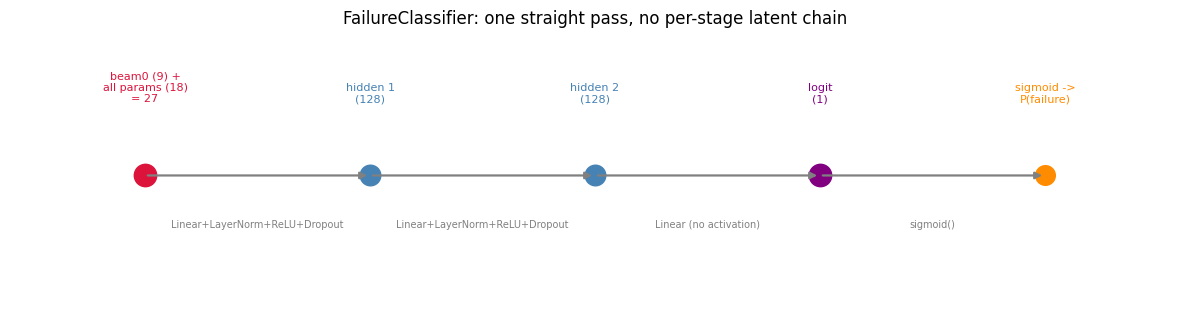

In [10]:
fig, ax = plt.subplots(figsize=(12, 3.2))

layer_x = [0, 1, 2, 3, 4]
layer_labels = [
    f'beam0 (9) +\nall params ({N_PARAMS})\n= {BEAM_STATE_DIM + N_PARAMS}',
    f'hidden 1\n({classifier.hidden_sizes[0]})',
    f'hidden 2\n({classifier.hidden_sizes[1]})',
    'logit\n(1)',
    'sigmoid ->\nP(failure)',
]
colors = ['crimson', 'steelblue', 'steelblue', 'purple', 'darkorange']
sizes = [260, 220, 220, 260, 200]

for x, label, color, size in zip(layer_x, layer_labels, colors, sizes):
    ax.scatter(x, 0, s=size, color=color, zorder=3)
    ax.text(x, 0.35, label, ha='center', va='bottom', fontsize=8, color=color)

edge_labels = ['Linear+LayerNorm+ReLU+Dropout', 'Linear+LayerNorm+ReLU+Dropout', 'Linear (no activation)', 'sigmoid()']
for i in range(len(layer_x) - 1):
    ax.annotate('', xy=(layer_x[i + 1], 0), xytext=(layer_x[i], 0),
                arrowprops=dict(arrowstyle='-|>', color='gray', lw=1.6))
    ax.text((layer_x[i] + layer_x[i + 1]) / 2, -0.25, edge_labels[i], ha='center', fontsize=7, color='gray')

ax.set_xlim(-0.6, 4.6)
ax.set_ylim(-0.6, 0.7)
ax.axis('off')
ax.set_title('FailureClassifier: one straight pass, no per-stage latent chain')
fig.tight_layout()
plt.show()